# Breast Cancer Detection Project

Steps to take:

Phase 1: Data and EDA
1. Get the data
2. EDA first - Check and Analyse
    - Feature Transformation: 
    - Standardization, Scale, or PCA
3. Feature Selection
4. Train test split

Phase 2: Model Building

5. Modelling
6. Testing

Phase 3: Deployment

7. Export the model
8. Check for important features

--

9. We write a function that takes those important values (4 top important ones), and makes a prediction on those, and returns the prediction
10. We will deploy the model on Gradio on Hugging Face
11. We will learn deployment with Streamlit as well

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# classification evaluation metrics are needed here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Data Acquired during the imports only
# let's build the entire dataframe first
df = pd.DataFrame(load_breast_cancer().data, columns =load_breast_cancer().feature_names)

df['target'] = load_breast_cancer().target

# if we want actual labels in the dataset
# df['target'] = df['target'].map({0 : 'Malignant', 1: 'Benign'})


# EDA
df.head()

df.shape

df.isnull().sum()

df.describe()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#### Let's find the most important features and use them only for this project


- we are checking the correlation matrix
- each feature will be compared with other features
- whichever features have high correlation values, will be kept
- or the other way is, to check correlation ONLY with the Target Column

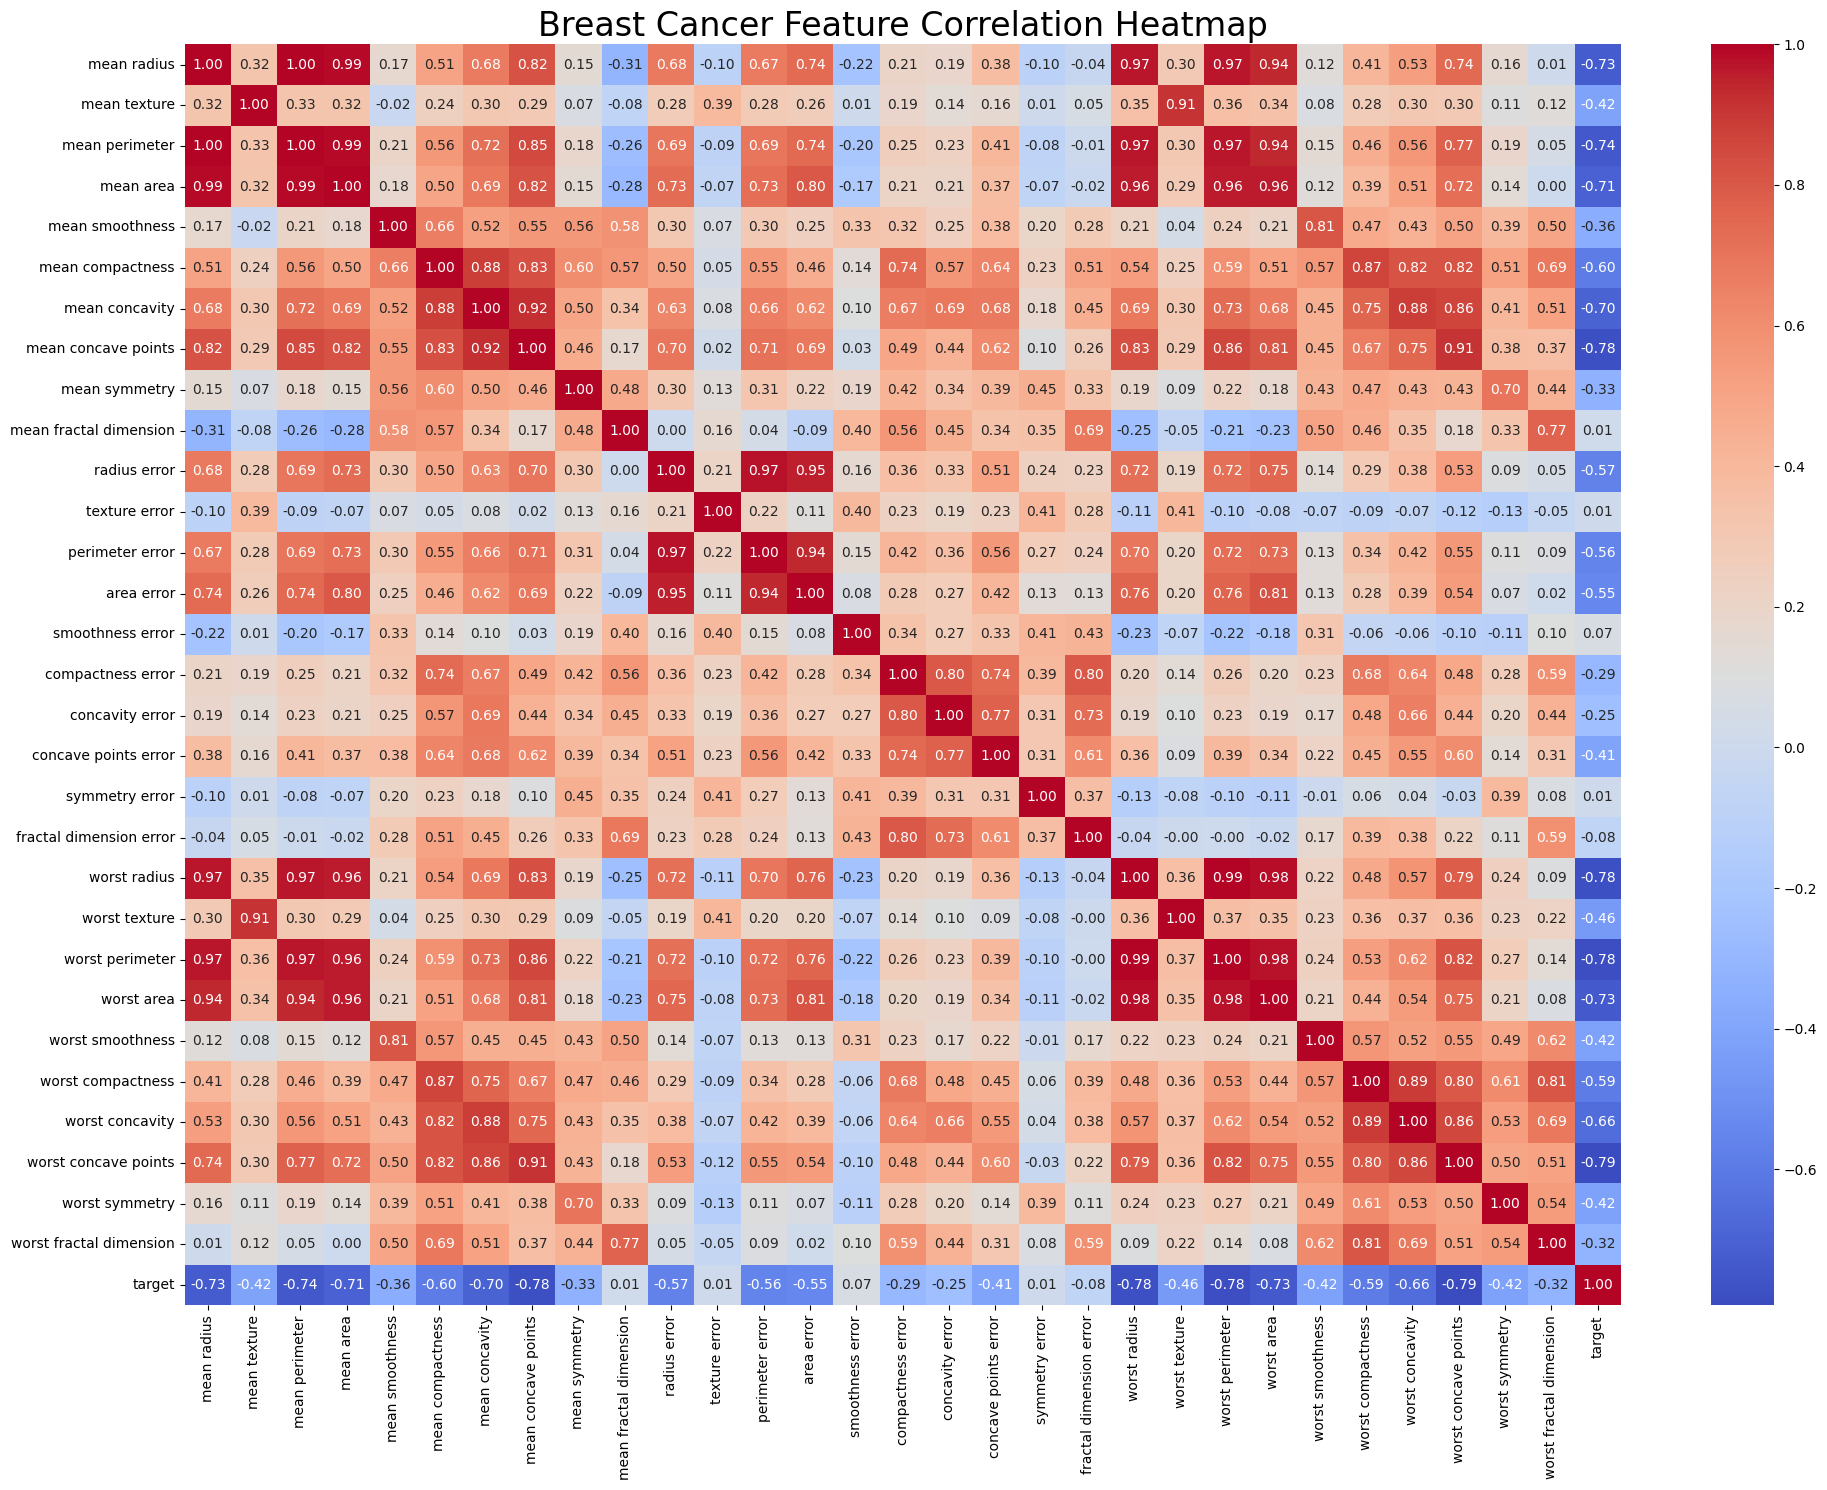

In [6]:
# Using correlation between the columns
corr_matrix = df.corr()
plt.figure(figsize= (20, 15))
sns.heatmap(df.corr(), annot= True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Breast Cancer Feature Correlation Heatmap", fontsize = 24)
plt.tight_layout()
plt.show()

In [ ]:
# Selecting columns only with high correlation
corr_matrix = df.corr()
np.fill_diagonal(corr_matrix.values, 0) # fill the diagonal with 0 instead of 1

threshold = 0.9
# use the list comprehension with expression
high_corr_cols = [col for col in corr_matrix.columns if corr_matrix[col].max() > threshold]
print(len(high_corr_cols))
print(high_corr_cols)



['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'radius error', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']


In [ ]:
# We can also, ONLY KEEP COLUMNs with high correlation with the target

corr_matrix = df.corr()['target']
corr_matrix['target'] = 0

threshold = 0.7
# use the list comprehension with expression
high_corr_target_cols = [col for col in corr_matrix.columns if corr_matrix[col].max() > threshold]

print(len(high_corr_target_cols))
print(high_corr_target_cols)



In [ ]:
# Feature selection


In [ ]:
print(load_breast_cancer().DESCR)

In [ ]:



# Feature Selection - already done by sklearn
X = load_breast_cancer().data

y = load_breast_cancer().target
# malignant or Benign
# Cancer - moving around cancer cell === Benign means local and dead

# train test split - 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y # homework for today
                                                    )



In [ ]:
# Random Forest Classifier
model_rf_clf = RandomForestClassifier(
    n_estimators = 10,
    random_state= 42
)

model_rf_clf.fit(X_train, y_train)

In [ ]:
print("="*30)


# Predictions for Random Forest
y_pred_test_rf = model_rf_clf.predict(X_test) # unseen data
y_pred_train_rf = model_rf_clf.predict(X_train) # model has seeen these inputs

# Evaluation of the model
test_acc_rf = accuracy_score(y_test, y_pred_test_rf) # Testing accuracy
train_acc_rf = accuracy_score(y_train, y_pred_train_rf) #  Training accuracy

print("====== Random Forest Evaluation ======")
print(f"Testing Accuracy: {test_acc_rf*100:.2f}%")
print(f"Training Accuracy: {train_acc_rf*100:.2f}%")


Now let’s see what happens if we **remove** the depth limit and allow the tree to grow deep.

We expect:

- **Train accuracy** ≈ 1.0 (almost perfect)
- **Test accuracy** may not improve much or may become worse  
  → model is overfitting (memorizing training data).


In [ ]:
importances = model_rf_clf.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending= False).head(7)

# plot importances

plt.barh(df_top_features['features'], df_top_features['importance'])
plt.gca().invert_yaxis() # invert the axis --- largest on TOP

plt.title("Random Forest Top 10 Important Features")
plt.grid()
plt.show()

### Saving an ML model

- When we train a model, we can save the trained model and use it somewhere else as well
- 
- What these files look like
- Using:
    - Pickle .pkl
    - Joblib .joblib
    - .keras, .h5 - TensorFlow way of saving - Framework by Google
    - onnx - opensource representation - a way to convert models around
    - .pt .pth - PyTorch way of saving - Framework by Meta/Facebook

**Pickle** is a standard Python library for serializing and deserializing Python objects, including machine learning models. It is easy to use but may not be secure for untrusted data

In [ ]:
import pickle
# Save model
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)
# Load model
with open('model.pkl', 'rb') as file:
    model = pickle.load(file)

**Joblib** is optimized for saving large NumPy arrays and is more efficient than Pickle for large models.

In [ ]:
import joblib 
# Save model
joblib.dump(model, 'model.joblib')
# Load model
model = joblib.load('model.joblib')

**JSON** You can save the model architecture as a JSON file, which is useful for custom models where you need full control over the restoration process.

In [ ]:
import joblib

